In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import time
import random
import multiprocessing
import matplotlib.pyplot as pl

In [2]:
# ==============================
# MERGE FUNCTION
# ==============================
def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result

In [3]:
# ==============================
# SEQUENTIAL MERGE SORT
# ==============================
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

In [4]:
# ==============================
# PARALLEL MERGE SORT
# ==============================
def parallel_merge_sort(arr):
    if len(arr) <= 1:
        return arr

    if len(arr) < 500:  # threshold (important)
        return merge_sort(arr)

    mid = len(arr) // 2

    with multiprocessing.Pool(2) as pool:
        left, right = pool.map(parallel_merge_sort, [arr[:mid], arr[mid:]])

    return merge(left, right)

In [5]:
# ==============================
# USER INPUT
# ==============================
n = int(input("Enter number of elements: "))
arr = list(map(int, input("Enter elements: ").split()))

# Copies
arr_seq = arr.copy()
arr_par = arr.copy()

Enter number of elements: 1000
Enter elements: 837 192 564 23 901 345 678 12 456 789 234 567 890 123 345 678 901 222 444 666 888 999 111 333 555 777 101 202 303 404 505 606 707 808 909 1000 876 543 210 432 654 876 109 321 543 765 987 135 246 357 468 579 680 791 802 913 24 68 92 136 180 224 268 312 356 400 444 488 532 576 620 664 708 752 796 840 884 928 972 16 48 80 112 144 176 208 240 272 304 336 368 400 432 464 496 528 560 592 624 656 688 720 752 784 816 848 880 912 944 976 8 40 72 104 136 168 200 232 264 296 328 360 392 424 456 488 520 552 584 616 648 680 712 744 776 808 840 872 904 936 968 3 6 9 15 18 21 27 30 33 36 39 42 45 48 51 54 57 60 63 66 69 72 75 78 81 84 87 90 93 96 99 102 105 108 111 114 117 120 123 126 129 132 135 138 141 144 147 150 153 156 159 162 165 168 171 174 177 180 183 186 189 192 195 198 201 204 207 210 213 216 219 222 225 228 231 234 237 240 243 246 249 252 255 258 261 264 267 270 273 276 279 282 285 288 291 294 297 300 301 302 304 305 306 307 308 309 310 311 31

In [6]:
# ==============================
# TIME MEASUREMENT
# ==============================
start = time.time()
sorted_seq = merge_sort(arr_seq)
end = time.time()
seq_time = end - start

start = time.time()
sorted_par = parallel_merge_sort(arr_par)
end = time.time()
par_time = end - start

In [7]:
# ==============================
# OUTPUT
# ==============================
print("\nSequential Sorted:", sorted_seq)
print("Parallel Sorted:", sorted_par)

print("\nSequential Time:", seq_time)
print("Parallel Time:", par_time)


Sequential Sorted: [3, 6, 8, 9, 12, 15, 16, 18, 21, 23, 24, 27, 30, 33, 36, 39, 40, 42, 45, 48, 48, 51, 54, 57, 60, 63, 66, 68, 69, 72, 72, 75, 78, 80, 81, 84, 87, 90, 92, 93, 96, 99, 101, 102, 104, 105, 108, 109, 111, 111, 112, 114, 117, 120, 123, 123, 126, 129, 132, 135, 135, 136, 136, 138, 141, 144, 144, 147, 150, 153, 156, 159, 162, 165, 168, 168, 171, 174, 176, 177, 180, 180, 183, 186, 189, 192, 192, 195, 198, 200, 201, 202, 204, 207, 208, 210, 210, 213, 216, 219, 222, 222, 224, 225, 228, 231, 232, 234, 234, 237, 240, 240, 243, 246, 246, 249, 252, 255, 258, 261, 264, 264, 267, 268, 270, 272, 273, 276, 279, 282, 285, 288, 291, 294, 296, 297, 300, 301, 302, 303, 304, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 357, 358, 359, 360, 361, 362, 363, 364, 365, 

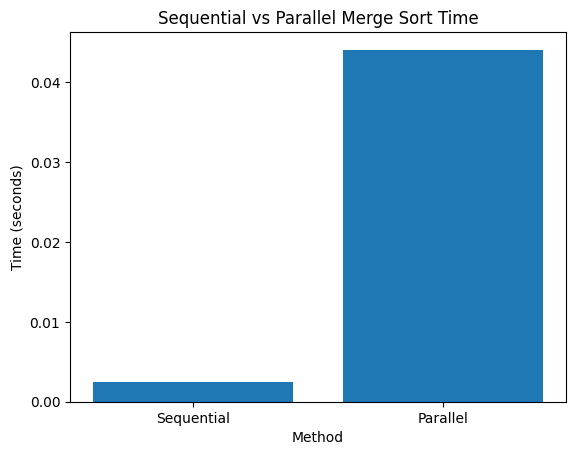

In [8]:
# ==============================
# GRAPH: TIME COMPARISON
# ==============================
pl.figure()

methods = ["Sequential", "Parallel"]
times = [seq_time, par_time]

pl.bar(methods, times)
pl.title("Sequential vs Parallel Merge Sort Time")
pl.xlabel("Method")
pl.ylabel("Time (seconds)")

pl.show()